# Lid Velocity Optimization via JAX Autodiff

**Goal:** Find the time-dependent lid velocity vector `a = [v1, v2, ..., v_nt]` that minimizes (or maximizes) the velocity at a fixed interior grid point.

**Imports:** `build_up_b`, `pressure_poisson`, and all grid parameters are loaded directly from `cavity_flow_jax.ipynb` — no code is duplicated here.

## 0 · Notebook Loader

In [1]:
import json

def run_notebook_cells(path, stop_on=None):
    with open(path) as f:
        nb = json.load(f)
    ns = {}
    for i, cell in enumerate(nb["cells"]):
        if cell["cell_type"] != "code":
            continue
        src = "".join(cell["source"])
        src = "\n".join(
            line for line in src.splitlines()
            if not line.strip().startswith("%")
        )
        if stop_on and stop_on in src:
            print(f"  Stopped before cell {i} (trigger: '{stop_on}')")
            break
        try:
            exec(src, ns)
        except Exception as e:
            print(f"  ⚠ Cell {i} skipped — {type(e).__name__}: {e}")
    return ns

## 1 · Import from JAX Solver Notebook

We stop before the cell that runs `cavity_flow` (which does the full 1000-step solve with a fixed lid) since we'll replace that with our own scan-based runner below.

In [2]:
print("Loading cavity_flow_jax.ipynb …")
jax_ns = run_notebook_cells(
    "cavity_flow_jax.ipynb",
    stop_on="u_sol, v_sol, p_sol = cavity_flow",  # stop before the solver runs
)

# --- Pull out what we need ---
import jax
import jax.numpy as jnp
import numpy as np

build_up_b       = jax_ns["build_up_b"]
pressure_poisson = jax_ns["pressure_poisson"]

nx  = jax_ns["nx"]
ny  = jax_ns["ny"]
nt  = jax_ns["nt"]
dx  = jax_ns["dx"]
dy  = jax_ns["dy"]
rho = jax_ns["rho"]
nu  = jax_ns["nu"]
dt  = jax_ns["dt"]

print(f"Imported: nx={nx}, ny={ny}, nt={nt}, dt={dt}, nu={nu}")
print(f"Functions: build_up_b={build_up_b}, pressure_poisson={pressure_poisson}")

Loading cavity_flow_jax.ipynb …
  Stopped before cell 5 (trigger: 'u_sol, v_sol, p_sol = cavity_flow')
Imported: nx=41, ny=41, nt=1000, dt=0.001, nu=0.1
Functions: build_up_b=<function build_up_b at 0x11c8fcae0>, pressure_poisson=<function pressure_poisson at 0x11c8fc900>


## 2 · Scan-Based Simulator

`run_sim(a)` takes the full lid velocity schedule `a` (shape `(nt,)`) and runs the Navier-Stokes solver using `jax.lax.scan`. This lets JAX differentiate through all timesteps efficiently.

In [3]:
def step_fn(carry, a_i):
    """One timestep of the Navier-Stokes solver.
    carry : (u, v, p)  — current flow state
    a_i   : scalar     — lid velocity for this timestep
    """
    u, v, p = carry

    b = build_up_b(jnp.zeros((nx, ny)), rho, dt, u, v, dx, dy)
    p = pressure_poisson(p, dx, dy, b)

    un, vn = u, v

    u = u.at[1:-1, 1:-1].set(
        un[1:-1, 1:-1]
        - un[1:-1, 1:-1] * dt/dx * (un[1:-1, 1:-1] - un[0:-2, 1:-1])
        - vn[1:-1, 1:-1] * dt/dy * (un[1:-1, 1:-1] - un[1:-1, 0:-2])
        - dt / (2*rho*dx) * (p[2:, 1:-1] - p[0:-2, 1:-1])
        + nu * (dt/dx**2 * (un[2:, 1:-1] - 2*un[1:-1, 1:-1] + un[0:-2, 1:-1])
              + dt/dy**2 * (un[1:-1, 2:] - 2*un[1:-1, 1:-1] + un[1:-1, 0:-2]))
    )
    v = v.at[1:-1, 1:-1].set(
        vn[1:-1, 1:-1]
        - un[1:-1, 1:-1] * dt/dx * (vn[1:-1, 1:-1] - vn[0:-2, 1:-1])
        - vn[1:-1, 1:-1] * dt/dy * (vn[1:-1, 1:-1] - vn[1:-1, 0:-2])
        - dt / (2*rho*dy) * (p[1:-1, 2:] - p[1:-1, 0:-2])
        + nu * (dt/dx**2 * (vn[2:, 1:-1] - 2*vn[1:-1, 1:-1] + vn[0:-2, 1:-1])
              + dt/dy**2 * (vn[1:-1, 2:] - 2*vn[1:-1, 1:-1] + vn[1:-1, 0:-2]))
    )

    # Wall BCs
    u = u.at[:, 0].set(0.0)
    u = u.at[0, :].set(0.0)
    u = u.at[-1, :].set(0.0)
    u = u.at[:, -1].set(a_i)   # ← time-varying lid velocity

    v = v.at[:, 0].set(0.0)
    v = v.at[:, -1].set(0.0)
    v = v.at[0, :].set(0.0)
    v = v.at[-1, :].set(0.0)

    return (u, v, p), None


def run_sim(a):
    """Run full simulation with lid schedule a (shape: nt,). Returns final u field."""
    u0 = jnp.zeros((nx, ny))
    v0 = jnp.zeros((nx, ny))
    p0 = jnp.zeros((nx, ny))
    (u_f, v_f, p_f), _ = jax.lax.scan(step_fn, (u0, v0, p0), a)
    return u_f

print("step_fn and run_sim defined.")

step_fn and run_sim defined.


## 3 · Pick a Random Interior Grid Point

In [4]:
key = jax.random.PRNGKey(42)
k1, k2 = jax.random.split(key)

# Stay away from walls (indices 0 and nx/ny-1)
i_pt = int(jax.random.randint(k1, (), 1, nx - 1))
j_pt = int(jax.random.randint(k2, (), 1, ny - 1))

print(f"Observing u at grid point ({i_pt}, {j_pt})")
print(f"Physical location: x={i_pt*dx:.3f}, y={j_pt*dy:.3f}")

Observing u at grid point (38, 22)
Physical location: x=0.950, y=0.550


## 4 · Loss Function and Gradient

$$L(\mathbf{a}) = u_{i,j}^{\text{final}}$$

We minimize this — so we're finding the lid schedule that makes the fluid at point $(i,j)$ move as slowly as possible. Flip the sign to maximize instead.

In [5]:
def loss(a):
    u_f = run_sim(a)
    return u_f[i_pt, j_pt]   # scalar

# Compile value + gradient together (one forward + one backward pass)
grad_fn = jax.jit(jax.value_and_grad(loss))

print("Loss and gradient function compiled.")
print("First call will be slow (XLA compilation) — subsequent calls will be fast.")

Loss and gradient function compiled.
First call will be slow (XLA compilation) — subsequent calls will be fast.


## 5 · Optimization Loop

Start with a constant lid velocity of 1.0 and use gradient descent to minimize the velocity at the target point.

In [6]:
a = jnp.ones(nt)   # initial guess: constant lid velocity = 1.0
lr = 1e-3
n_iters = 50

loss_history = []
grad_norm_history = []

for i in range(n_iters):
    val, grads = grad_fn(a)
    a = a - lr * grads

    loss_history.append(float(val))
    grad_norm_history.append(float(jnp.linalg.norm(grads)))

    if i % 10 == 0:
        print(f"iter {i:3d}  u[{i_pt},{j_pt}]={val:.6f}  |grad|={jnp.linalg.norm(grads):.4e}")

print("\nDone.")

iter   0  u[38,22]=-0.013660  |grad|=1.7543e-03
iter  10  u[38,22]=-0.013660  |grad|=1.7543e-03
iter  20  u[38,22]=-0.013660  |grad|=1.7543e-03
iter  30  u[38,22]=-0.013660  |grad|=1.7543e-03
iter  40  u[38,22]=-0.013660  |grad|=1.7543e-03

Done.


## 6 · Results

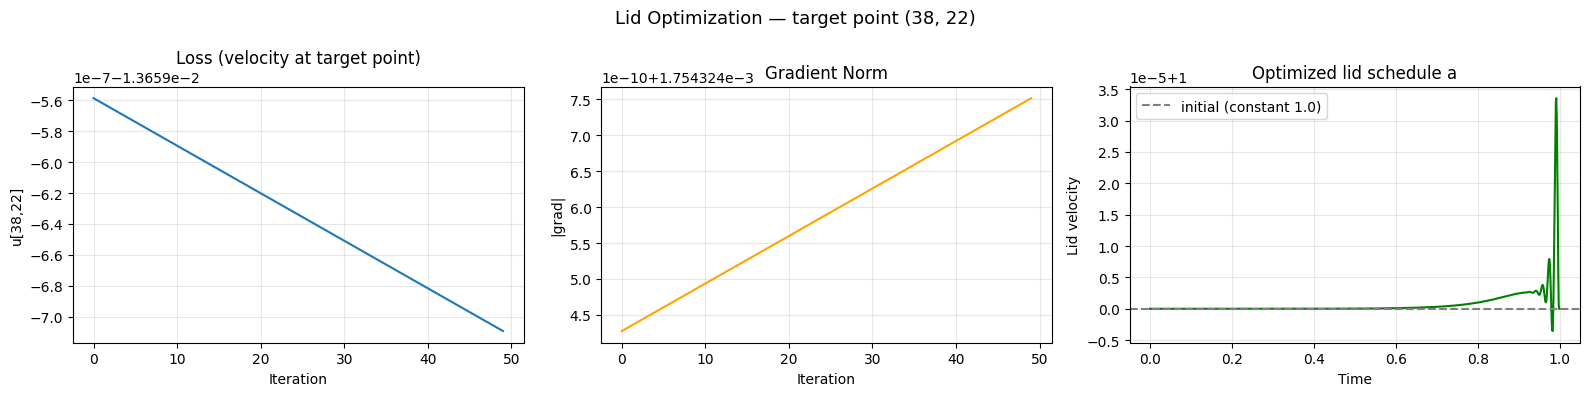

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle(f"Lid Optimization — target point ({i_pt}, {j_pt})", fontsize=13)

# Loss over iterations
axes[0].plot(loss_history)
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel(f"u[{i_pt},{j_pt}]")
axes[0].set_title("Loss (velocity at target point)")
axes[0].grid(alpha=0.3)

# Gradient norm over iterations
axes[1].plot(grad_norm_history, color="orange")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("|grad|")
axes[1].set_title("Gradient Norm")
axes[1].grid(alpha=0.3)

# Optimized lid velocity schedule a over time
t_vals = np.arange(nt) * dt
axes[2].plot(t_vals, np.array(a), color="green")
axes[2].axhline(1.0, color="gray", linestyle="--", label="initial (constant 1.0)")
axes[2].set_xlabel("Time")
axes[2].set_ylabel("Lid velocity")
axes[2].set_title("Optimized lid schedule a")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7 · Gradient Sensitivity — Which Timesteps Matter Most?

Plot `dL/da` to see which moments in the lid's history have the most influence on the target point.

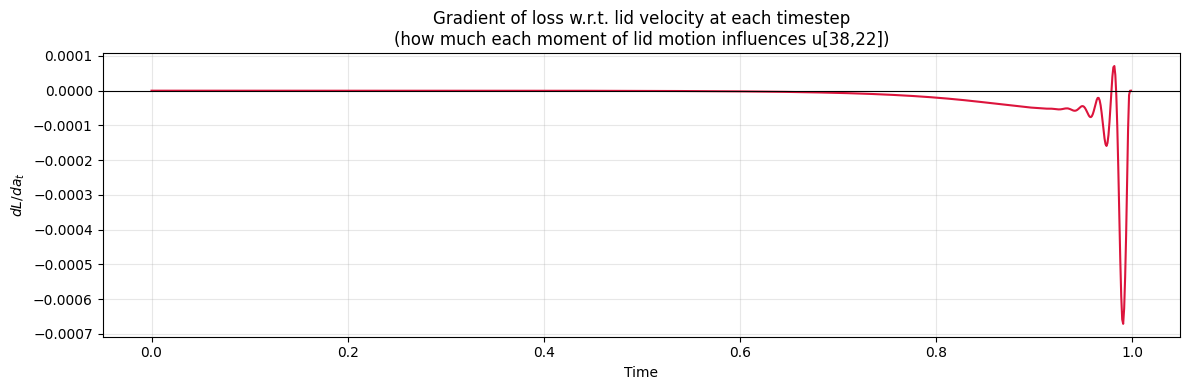

In [8]:
# Recompute gradient at the final optimized a
_, final_grads = grad_fn(a)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t_vals, np.array(final_grads), color="crimson")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Time")
ax.set_ylabel(r"$dL/da_t$")
ax.set_title(f"Gradient of loss w.r.t. lid velocity at each timestep\n"
             f"(how much each moment of lid motion influences u[{i_pt},{j_pt}])")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()